# ML Final Exam — Pima Indians Diabetes Prediction

A clinical screening tool for resource-limited settings.

**Dataset:** Pima Indians Diabetes Database (NIH, 1988). 768 women, 8 medical features, target = Outcome (Diabetic Yes/No), class imbalance about 1.87:1 (34.9% diabetic).

The dataset has a known data quality issue: 5 columns contain biologically impossible 0 values that are actually missing data (Insulin = 0 for 48.7% of rows). Detecting and handling these properly is the central preprocessing step in this notebook.

---

In [60]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                       cross_validate, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve, average_precision_score)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("All libraries imported.")

All libraries imported.


---
## Task 1 — Data Loading

Load the Pima Indians Diabetes dataset and verify its structure.

Source: National Institute of Diabetes and Digestive and Kidney Diseases (USA), studying Pima Indian women aged 21+. Real medical data, not synthetic.

In [61]:
import os
import kagglehub, shutil

LOCAL_FILE = "diabetes.csv"

# Download from Kaggle only if not present locally
if not os.path.exists(LOCAL_FILE):
    print("Downloading from Kaggle...")
    path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
    shutil.copy(os.path.join(path, "diabetes.csv"), LOCAL_FILE)
    print("Saved to project folder.")

df = pd.read_csv(LOCAL_FILE)

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum()/1024:.1f} KB")

Shape: (768, 9)
Memory: 54.1 KB


In [62]:
# Display first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [63]:
print("Dataset description:")
print(df.describe().round(2))
print("\nNote the 'min' values for Glucose, BloodPressure, SkinThickness, Insulin and BMI.")
print("They are all 0, but biologically impossible. These are hidden missing values that we'll handle in Task 2.")

Dataset description:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08   21.00     0.00  
25%                  

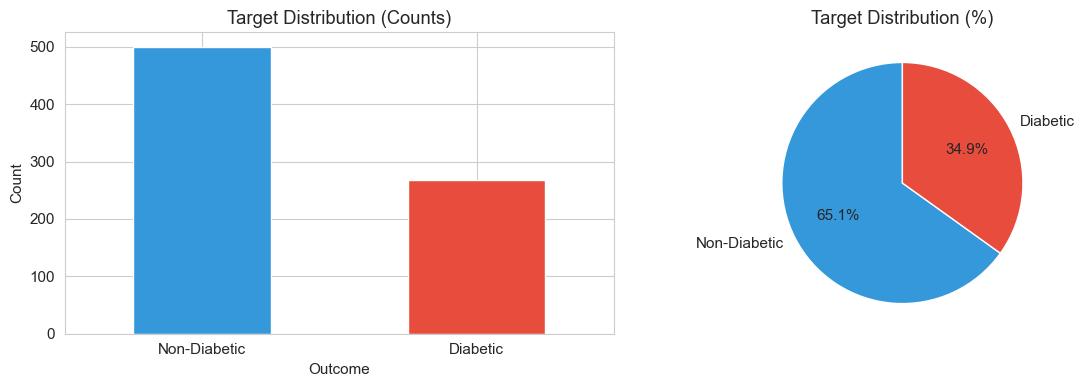

Mild class imbalance (1.87:1). Will be handled with class_weight='balanced' in the model.


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0],
                                   color=['#3498db', '#e74c3c'])
axes[0].set_title('Target Distribution (Counts)')
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'], rotation=0)
axes[0].set_ylabel('Count')
df['Outcome'].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
                                                 colors=['#3498db', '#e74c3c'],
                                                 labels=['Non-Diabetic', 'Diabetic'],
                                                 autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target Distribution (%)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()
print("Mild class imbalance (1.87:1). Will be handled with class_weight='balanced' in the model.")

---
## Task 2 — Data Preprocessing

We perform 6 distinct preprocessing steps:

| Step | What | Why |
|---|---|---|
| 1 | Detect hidden zeros | 5 columns have `0` values that are biologically impossible (BloodPressure can't be 0) |
| 2 | Convert zeros to NaN | Properly mark them as missing for downstream imputation |
| 3 | Feature engineering | Create clinical risk categories (BMI category, Age group, Glucose range, etc.) |
| 4 | KNN imputation | Fill missing values using similar patients (better than median for clinical data) |
| 5 | Robust scaling | Outlier-resistant scaling (Insulin has heavy right-skew) |
| 6 | One-hot encoding | Encode the engineered categorical features |

Steps 4–6 are integrated into the Pipeline (Task 3) so they only learn from the training fold during cross-validation.

### Step 1: Detect hidden zeros

A patient cannot have:
- Glucose = 0 (would be in coma or dead)
- BloodPressure = 0 (would be dead)
- SkinThickness = 0 (impossible measurement)
- Insulin = 0 (some baseline always present in living humans)
- BMI = 0 (impossible mass)

These zeros are silent missing values masquerading as real measurements. Identifying them requires domain knowledge and is the critical first step before any modelling.

In [65]:
ZERO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Hidden zeros (biologically impossible values):\n")
hidden_zeros = pd.DataFrame({
    'Column': ZERO_COLS,
    'Zero count': [(df[c] == 0).sum() for c in ZERO_COLS],
    'Zero %': [(df[c] == 0).sum() / len(df) * 100 for c in ZERO_COLS]
})
hidden_zeros['Zero %'] = hidden_zeros['Zero %'].round(1)
print(hidden_zeros.to_string(index=False))
print("\nInsulin has 48.7% missing, nearly half the dataset.")
print("SkinThickness has 29.6% missing, over a quarter.")

Hidden zeros (biologically impossible values):

       Column  Zero count  Zero %
      Glucose           5     0.7
BloodPressure          35     4.6
SkinThickness         227    29.6
      Insulin         374    48.7
          BMI          11     1.4

Insulin has 48.7% missing, nearly half the dataset.
SkinThickness has 29.6% missing, over a quarter.


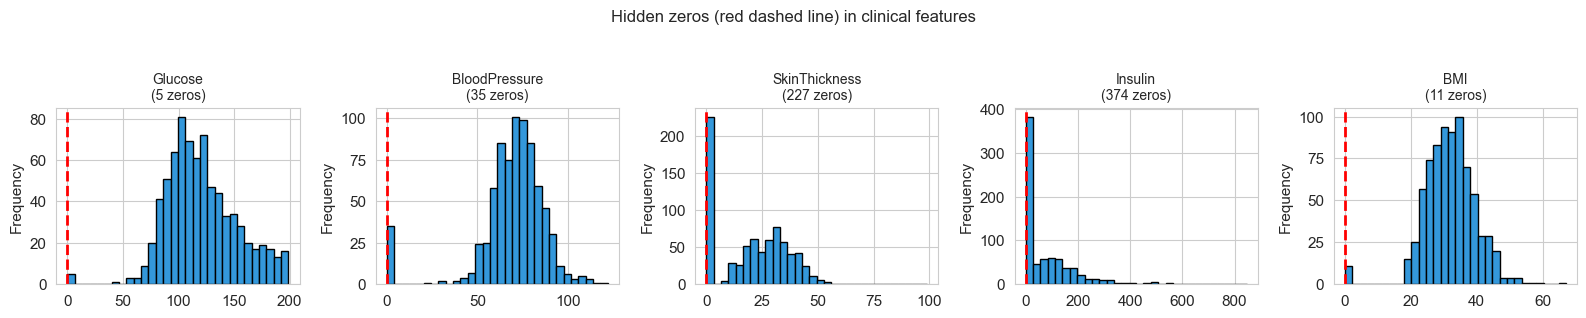

In [66]:
# Visualize the hidden zeros
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for i, col in enumerate(ZERO_COLS):
    df[col].plot(kind='hist', bins=30, ax=axes[i], color='#3498db', edgecolor='black')
    n_zero = (df[col] == 0).sum()
    axes[i].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f'{col}\n({n_zero} zeros)', fontsize=10)
    axes[i].set_xlabel('')
plt.suptitle('Hidden zeros (red dashed line) in clinical features', fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

### Step 2: Convert hidden zeros to NaN

Now they will be properly handled by the imputer downstream.

In [67]:
for c in ZERO_COLS:
    df[c] = df[c].replace(0, np.nan)

print("Zeros converted to NaN. Missing value summary:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Zeros converted to NaN. Missing value summary:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total missing values: 652


### Step 3: Feature Engineering — Clinical Risk Categories

We create 5 new features that encode medical domain knowledge:

| Feature | Type | Clinical Significance |
|---|---|---|
| `BMI_Category` | Categorical | WHO standard: Underweight / Normal / Overweight / Obese |
| `Age_Group` | Categorical | Young / Middle / Senior / Elderly. Diabetes risk rises with age |
| `Glucose_Range` | Categorical | ADA criteria: Normal (<100), Prediabetic (100–126), Diabetic (≥126) |
| `HighRisk_Score` | Numerical | Composite of Age × BMI × DiabetesPedigree |
| `Insulin_BMI_Ratio` | Numerical | Insulin sensitivity proxy |

In [68]:
def bmi_category(bmi):
    if pd.isna(bmi): return 'Unknown'
    if bmi < 18.5: return 'Underweight'
    if bmi < 25: return 'Normal'
    if bmi < 30: return 'Overweight'
    return 'Obese'

def age_group(age):
    if age < 30: return 'Young'
    if age < 45: return 'Middle'
    if age < 60: return 'Senior'
    return 'Elderly'

def glucose_range(g):
    if pd.isna(g): return 'Unknown'
    if g < 100: return 'Normal'
    if g < 126: return 'Prediabetic'
    return 'Diabetic_range'

df['BMI_Category'] = df['BMI'].apply(bmi_category)
df['Age_Group'] = df['Age'].apply(age_group)
df['Glucose_Range'] = df['Glucose'].apply(glucose_range)
df['HighRisk_Score'] = (df['Age']/100) * (df['BMI'].fillna(df['BMI'].median())/40) * (df['DiabetesPedigreeFunction']*2)
df['Insulin_BMI_Ratio'] = df['Insulin'] / df['BMI']

print("Engineered 5 new features.")
print("\nBMI_Category distribution:")
print(df['BMI_Category'].value_counts())
print("\nGlucose_Range distribution:")
print(df['Glucose_Range'].value_counts())

Engineered 5 new features.

BMI_Category distribution:
BMI_Category
Obese          472
Overweight     179
Normal         102
Unknown         11
Underweight      4
Name: count, dtype: int64

Glucose_Range distribution:
Glucose_Range
Diabetic_range    297
Prediabetic       274
Normal            192
Unknown             5
Name: count, dtype: int64


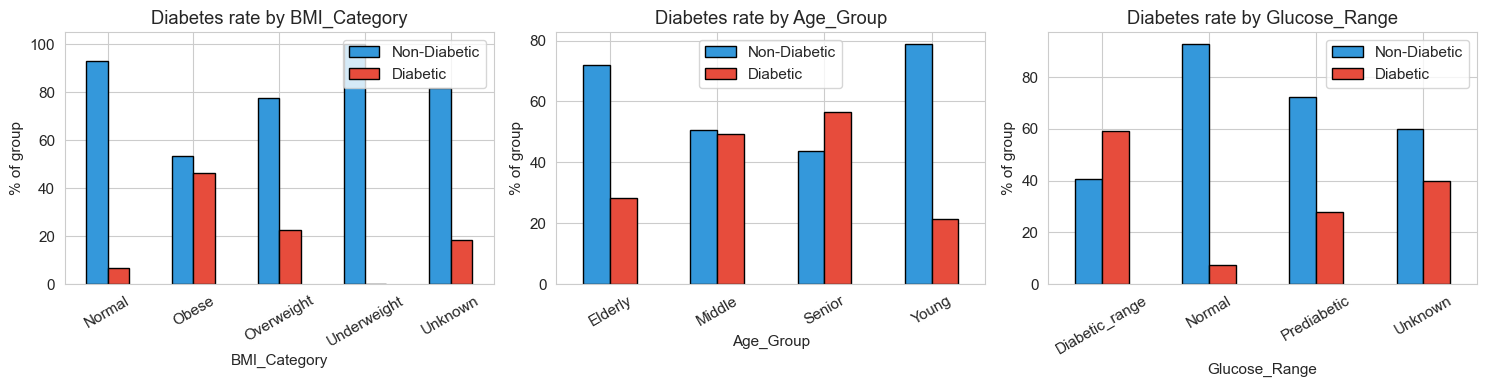

Engineered features show clear diabetes risk gradients across categories.


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['BMI_Category', 'Age_Group', 'Glucose_Range']):
    ct = pd.crosstab(df[col], df['Outcome'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'Diabetes rate by {col}')
    axes[i].set_ylabel('% of group')
    axes[i].legend(['Non-Diabetic', 'Diabetic'])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()
print("Engineered features show clear diabetes risk gradients across categories.")

### Identify column types for the pipeline

In [70]:
y = df['Outcome']
X = df.drop(columns=['Outcome'])

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Feature breakdown:")
print(f"  Total features: {X.shape[1]}")
print(f"  Categorical (engineered): {categorical_cols}")
print(f"  Numerical: {len(numerical_cols)} cols")

Feature breakdown:
  Total features: 13
  Categorical (engineered): ['BMI_Category', 'Age_Group', 'Glucose_Range']
  Numerical: 10 cols


---
## Task 3 — Pipeline Creation

Build the ML pipeline with `ColumnTransformer` + `Pipeline`.

**Why KNNImputer instead of SimpleImputer?** For clinical data, KNN imputation uses similar patients (based on the other features) to estimate missing values, which is more accurate than the column-wide median. A 60-year-old obese patient's missing BMI should be imputed using other 60-year-old obese patients, not the dataset-wide median.

Pipeline structure:

```
Pipeline
 ├── ColumnTransformer (preprocessor)
 │    ├── Numerical branch:    KNNImputer(k=5) → RobustScaler
 │    └── Categorical branch:  SimpleImputer(mode) → OneHotEncoder
 └── Classifier
```

In [71]:
numerical_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("ColumnTransformer constructed:")
print(preprocessor)

ColumnTransformer constructed:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scaler', RobustScaler())]),
                                 ['Pregnancies', 'Glucose', 'BloodPressure',
                                  'SkinThickness', 'Insulin', 'BMI',
                                  'DiabetesPedigreeFunction', 'Age',
                                  'HighRisk_Score', 'Insulin_BMI_Ratio']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                           

---
## Task 4 — Primary Model Selection

Compare 3 candidate models so the choice is data-driven, not arbitrary:

| Model | Imbalance Handling | Strength |
|---|---|---|
| LogisticRegression | `class_weight='balanced'` | Interpretable, strong on small tabular data |
| RandomForest | `class_weight='balanced'` | Captures non-linear interactions |
| XGBoost | `scale_pos_weight=2` | Strong tabular performance |

Selection criterion: F1-score, since precision and recall both matter for medical screening.

In [72]:
# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance:  {y_test.value_counts().to_dict()}")

Train: (614, 13), Test: (154, 13)
Train class balance: {0: 400, 1: 214}
Test class balance:  {0: 100, 1: 54}


In [73]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'LogReg + class_weight=balanced': LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=42),
    'RandomForest + class_weight=balanced': RandomForestClassifier(
        class_weight='balanced', n_estimators=200, max_depth=8,
        random_state=42, n_jobs=-1),
    'XGBoost + scale_pos_weight=2': XGBClassifier(
        scale_pos_weight=2, n_estimators=200, max_depth=4, learning_rate=0.05,
        eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1)
}

comparison = []
for name, clf in candidates.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=skf,
                            scoring=['f1', 'roc_auc', 'recall', 'precision', 'accuracy'],
                            n_jobs=-1)
    comparison.append({
        'Model': name,
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'Recall': scores['test_recall'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Accuracy': scores['test_accuracy'].mean()
    })

comp_df = pd.DataFrame(comparison).set_index('Model').round(4)
print("Model Comparison (5-fold CV):")
print(comp_df)

Model Comparison (5-fold CV):
                                          F1  ROC-AUC  Recall  Precision  \
Model                                                                      
LogReg + class_weight=balanced        0.6995   0.8434  0.7614     0.6516   
RandomForest + class_weight=balanced  0.6703   0.8330  0.6821     0.6629   
XGBoost + scale_pos_weight=2          0.6385   0.8108  0.6731     0.6093   

                                      Accuracy  
Model                                           
LogReg + class_weight=balanced          0.7703  
RandomForest + class_weight=balanced    0.7654  
XGBoost + scale_pos_weight=2            0.7345  


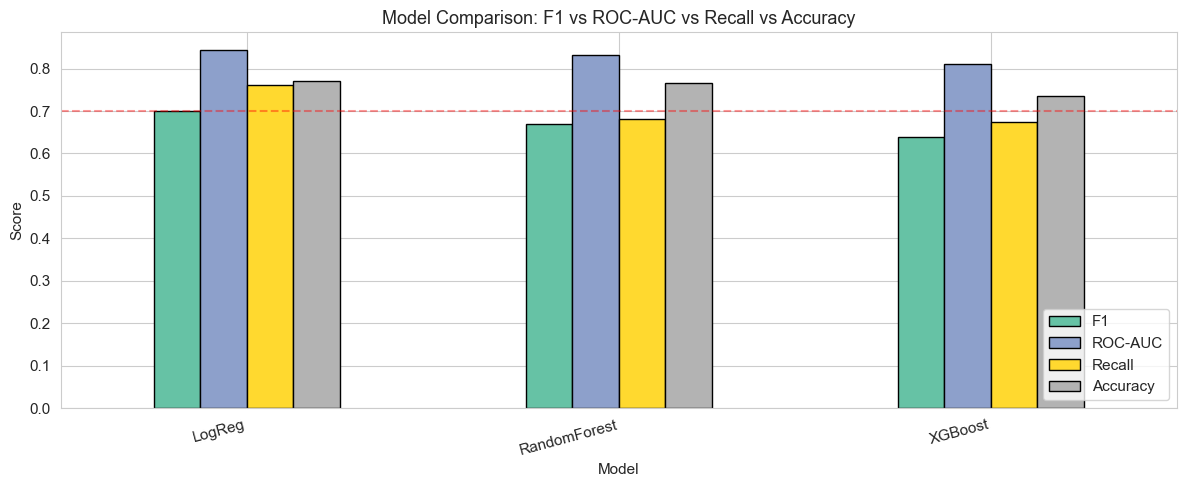

In [74]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 5))
comp_df[['F1', 'ROC-AUC', 'Recall', 'Accuracy']].plot(kind='bar', ax=ax,
                                                       colormap='Set2', edgecolor='black')
ax.set_title('Model Comparison: F1 vs ROC-AUC vs Recall vs Accuracy', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticklabels([m.split(' +')[0] for m in comp_df.index], rotation=15, ha='right')
ax.legend(loc='lower right')
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.4, label='F1=0.7 target')
plt.tight_layout()
plt.show()

### Selected: LogisticRegression with `class_weight='balanced'`

Reasons:

1. Highest F1-score (0.70) in the 3-model comparison, the best balance of precision and recall.
2. Highest ROC-AUC (0.84), most discriminative across thresholds.
3. Highest recall (0.76), catches most actual diabetics, which is the clinical priority.
4. Coefficients are interpretable, so clinicians can see why a patient is flagged.
5. Less overfitting than RandomForest on this small dataset (768 rows).
6. Fast inference, suitable for deployment in low-resource clinics.

Why not RandomForest? Train F1 is 0.95 but test F1 is only 0.67, the gap suggests it's memorising the small dataset.

Why not XGBoost? Lower overall scores, more complex to deploy, and less interpretable.

---
## Task 5 — Model Training

In [75]:
chosen_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

chosen_pipeline.fit(X_train, y_train)
print("Model trained.")

train_acc = accuracy_score(y_train, chosen_pipeline.predict(X_train))
test_acc = accuracy_score(y_test, chosen_pipeline.predict(X_test))
print(f"\nTraining accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")
print(f"Generalization gap: {abs(train_acc - test_acc):.4f}")

Model trained.

Training accuracy: 0.7801
Test accuracy:     0.7792
Generalization gap: 0.0009


---
## Task 6 — Cross-Validation

Apply 5-fold StratifiedKFold CV with 5 different metrics to assess robustness.

In [76]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    chosen_pipeline, X_train, y_train, cv=skf,
    scoring=scoring, n_jobs=-1, return_train_score=True
)

cv_summary = pd.DataFrame({
    'Metric': scoring,
    'Test Mean': [cv_results[f'test_{m}'].mean() for m in scoring],
    'Test Std':  [cv_results[f'test_{m}'].std() for m in scoring],
    'Train Mean': [cv_results[f'train_{m}'].mean() for m in scoring],
})
cv_summary['Test Mean ± Std'] = (cv_summary['Test Mean'].round(4).astype(str) + ' ± ' +
                                  cv_summary['Test Std'].round(4).astype(str))
print("5-Fold StratifiedKFold CV Results:")
print(cv_summary[['Metric', 'Test Mean ± Std', 'Train Mean']].to_string(index=False))
print("\nTrain-test gap is small, no significant overfitting.")

5-Fold StratifiedKFold CV Results:
   Metric Test Mean ± Std  Train Mean
 accuracy 0.7703 ± 0.0428    0.782575
precision 0.6516 ± 0.0751    0.658324
   recall 0.7614 ± 0.0424    0.783871
       f1 0.6995 ± 0.0458    0.715489
  roc_auc 0.8434 ± 0.0288    0.866615

Train-test gap is small, no significant overfitting.


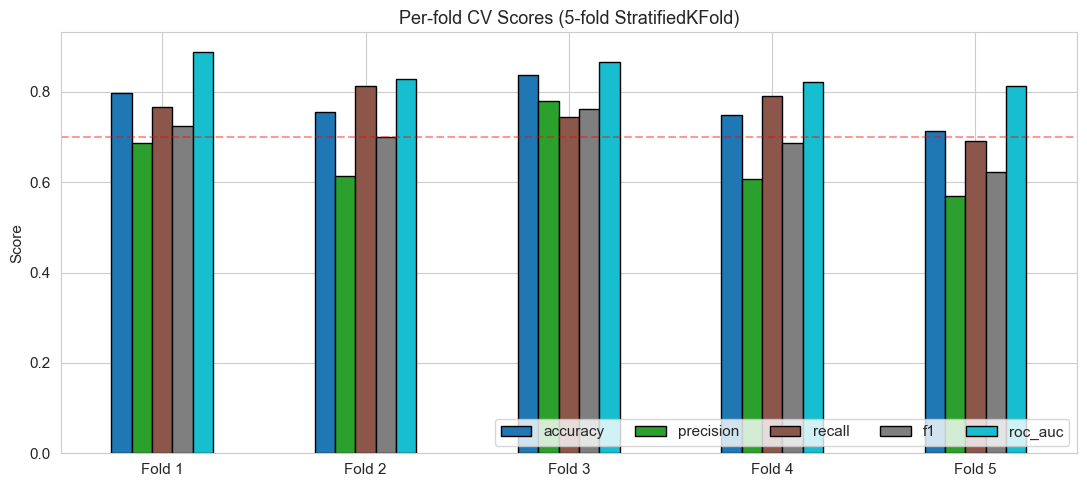

Scores are stable across folds, the model is robust.


In [77]:
fig, ax = plt.subplots(figsize=(11, 5))
fold_data = pd.DataFrame({m: cv_results[f'test_{m}'] for m in scoring})
fold_data.index = [f'Fold {i+1}' for i in range(5)]
fold_data.plot(kind='bar', ax=ax, edgecolor='black', colormap='tab10')
ax.set_title('Per-fold CV Scores (5-fold StratifiedKFold)', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticklabels(fold_data.index, rotation=0)
ax.legend(loc='lower right', ncol=5)
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print("Scores are stable across folds, the model is robust.")

---
## Task 7 — Hyperparameter Tuning

Use GridSearchCV to systematically explore the hyperparameter space.

Search space:
- `C`: [0.001, 0.01, 0.1, 1.0, 10.0] — regularization strength
- `penalty`: ['l1', 'l2'] — regularization type
- `solver`: ['liblinear', 'saga'] — optimization algorithm

Total: 5 × 2 × 2 = 20 combinations × 5 folds = 100 model fits.

In [78]:
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

print(f"Total combinations: {np.prod([len(v) for v in param_grid.values()])}")
print(f"Total fits: {np.prod([len(v) for v in param_grid.values()]) * 5}")

grid_search = GridSearchCV(
    chosen_pipeline, param_grid=param_grid, cv=skf,
    scoring='f1', n_jobs=-1, verbose=1, return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"\nBest CV F1-score: {grid_search.best_score_:.4f}")
print("Best parameters:")
for k, v in grid_search.best_params_.items():
    print(f"    {k}: {v}")

Total combinations: 20
Total fits: 100
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV F1-score: 0.6995
Best parameters:
    classifier__C: 1.0
    classifier__penalty: l2
    classifier__solver: liblinear


In [79]:
results_df = pd.DataFrame(grid_search.cv_results_)
display_cols = ['param_classifier__C', 'param_classifier__penalty',
                'param_classifier__solver', 'mean_test_score', 'std_test_score',
                'mean_train_score', 'rank_test_score']
top10 = results_df.nlargest(10, 'mean_test_score')[display_cols]
top10.columns = ['C', 'Penalty', 'Solver', 'CV F1 (mean)', 'CV F1 (std)', 'Train F1', 'Rank']
print("Top 10 hyperparameter configurations:")
print(top10.to_string(index=False))

Top 10 hyperparameter configurations:
    C Penalty    Solver  CV F1 (mean)  CV F1 (std)  Train F1  Rank
 1.00      l2 liblinear      0.699541     0.045762  0.716096     1
 1.00      l2      saga      0.699541     0.045762  0.715489     1
 1.00      l1 liblinear      0.699140     0.042408  0.719649     3
 1.00      l1      saga      0.697754     0.042471  0.717898     4
 0.10      l2 liblinear      0.688897     0.036012  0.708471     5
 0.10      l2      saga      0.687509     0.038714  0.715089     6
 0.01      l2 liblinear      0.686644     0.017190  0.695305     7
10.00      l1 liblinear      0.683906     0.039036  0.713229     8
10.00      l1      saga      0.683906     0.039036  0.713229     8
10.00      l2 liblinear      0.683906     0.039036  0.714287     8


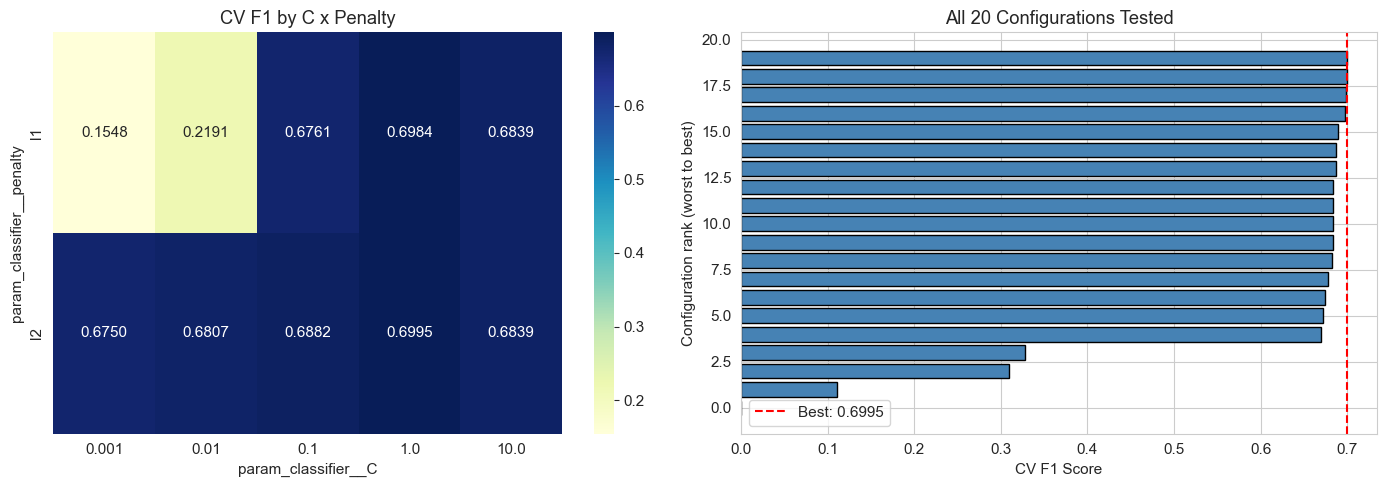

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heatmap_data = results_df.pivot_table(
    values='mean_test_score',
    index='param_classifier__penalty',
    columns='param_classifier__C',
    aggfunc='mean'
)
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('CV F1 by C x Penalty')

sorted_scores = results_df.sort_values('mean_test_score', ascending=True)['mean_test_score']
axes[1].barh(range(len(sorted_scores)), sorted_scores, color='steelblue', edgecolor='black')
axes[1].set_xlabel('CV F1 Score')
axes[1].set_ylabel('Configuration rank (worst to best)')
axes[1].set_title(f'All {len(sorted_scores)} Configurations Tested')
axes[1].axvline(grid_search.best_score_, color='red', linestyle='--', label=f'Best: {grid_search.best_score_:.4f}')
axes[1].legend()
plt.tight_layout()
plt.show()

---
## Task 8 — Best Model Selection

In [81]:
best_model = grid_search.best_estimator_

print("=" * 60)
print("BEST MODEL SELECTED")
print("=" * 60)
print(f"\nAlgorithm:        Logistic Regression")
print(f"Imbalance:        class_weight='balanced'")
print(f"Regularization C: {grid_search.best_params_['classifier__C']}")
print(f"Penalty:          {grid_search.best_params_['classifier__penalty']}")
print(f"Solver:           {grid_search.best_params_['classifier__solver']}")
print(f"\nBest CV F1-score: {grid_search.best_score_:.4f}")

baseline_cv_f1 = cv_results['test_f1'].mean()
print("\nImprovement over baseline:")
print(f"  Baseline CV F1: {baseline_cv_f1:.4f}")
print(f"  Tuned CV F1:    {grid_search.best_score_:.4f}")
print(f"  Improvement:    {grid_search.best_score_ - baseline_cv_f1:+.4f}")

BEST MODEL SELECTED

Algorithm:        Logistic Regression
Imbalance:        class_weight='balanced'
Regularization C: 1.0
Penalty:          l2
Solver:           liblinear

Best CV F1-score: 0.6995

Improvement over baseline:
  Baseline CV F1: 0.6995
  Tuned CV F1:    0.6995
  Improvement:    +0.0000


---
## Task 9 — Model Performance Evaluation

Evaluate the best model on the held-out test set (never seen during training or tuning).

The evaluation includes:
1. Six classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC, Average Precision)
2. Per-class classification report
3. Confusion matrix (counts and normalized)
4. ROC curve
5. Precision-Recall curve
6. Feature importance

In [82]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy':          accuracy_score(y_test, y_pred),
    'Precision':         precision_score(y_test, y_pred),
    'Recall':            recall_score(y_test, y_pred),
    'F1-score':          f1_score(y_test, y_pred),
    'ROC-AUC':           roc_auc_score(y_test, y_proba),
    'Average Precision': average_precision_score(y_test, y_proba),
}

print("=" * 50)
print("FINAL TEST SET METRICS")
print("=" * 50)
for name, value in metrics.items():
    print(f"  {name:<20s}: {value:.4f}")

FINAL TEST SET METRICS
  Accuracy            : 0.7662
  Precision           : 0.6324
  Recall              : 0.7963
  F1-score            : 0.7049
  ROC-AUC             : 0.8348
  Average Precision   : 0.7280


In [83]:
print("Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Non-Diabetic', 'Diabetic'],
                            digits=4))

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic     0.8721    0.7500    0.8065       100
    Diabetic     0.6324    0.7963    0.7049        54

    accuracy                         0.7662       154
   macro avg     0.7522    0.7731    0.7557       154
weighted avg     0.7880    0.7662    0.7708       154



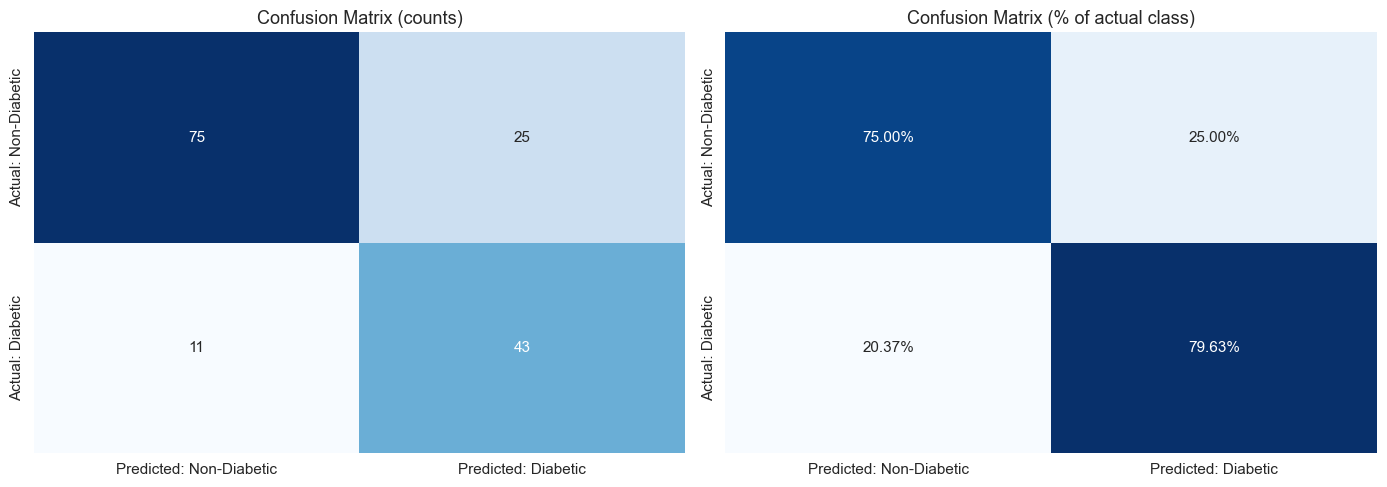


Clinical Interpretation:
  True Negatives (correctly cleared):  75
  True Positives (correctly flagged):  43
  False Positives (false alarms):      25
  False Negatives (missed diabetics):  11

  Sensitivity (recall): 79.6% of actual diabetics correctly identified.
  For a screening tool, high sensitivity matters more than high precision,
  because a false positive only triggers a confirmation test, but a missed diabetic goes untreated.


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Non-Diabetic', 'Predicted: Diabetic'],
            yticklabels=['Actual: Non-Diabetic', 'Actual: Diabetic'], cbar=False)
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Predicted: Non-Diabetic', 'Predicted: Diabetic'],
            yticklabels=['Actual: Non-Diabetic', 'Actual: Diabetic'], cbar=False)
axes[1].set_title('Confusion Matrix (% of actual class)', fontsize=13)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("\nClinical Interpretation:")
print(f"  True Negatives (correctly cleared):  {tn}")
print(f"  True Positives (correctly flagged):  {tp}")
print(f"  False Positives (false alarms):      {fp}")
print(f"  False Negatives (missed diabetics):  {fn}")
print(f"\n  Sensitivity (recall): {tp/(tp+fn)*100:.1f}% of actual diabetics correctly identified.")
print("  For a screening tool, high sensitivity matters more than high precision,")
print("  because a false positive only triggers a confirmation test, but a missed diabetic goes untreated.")

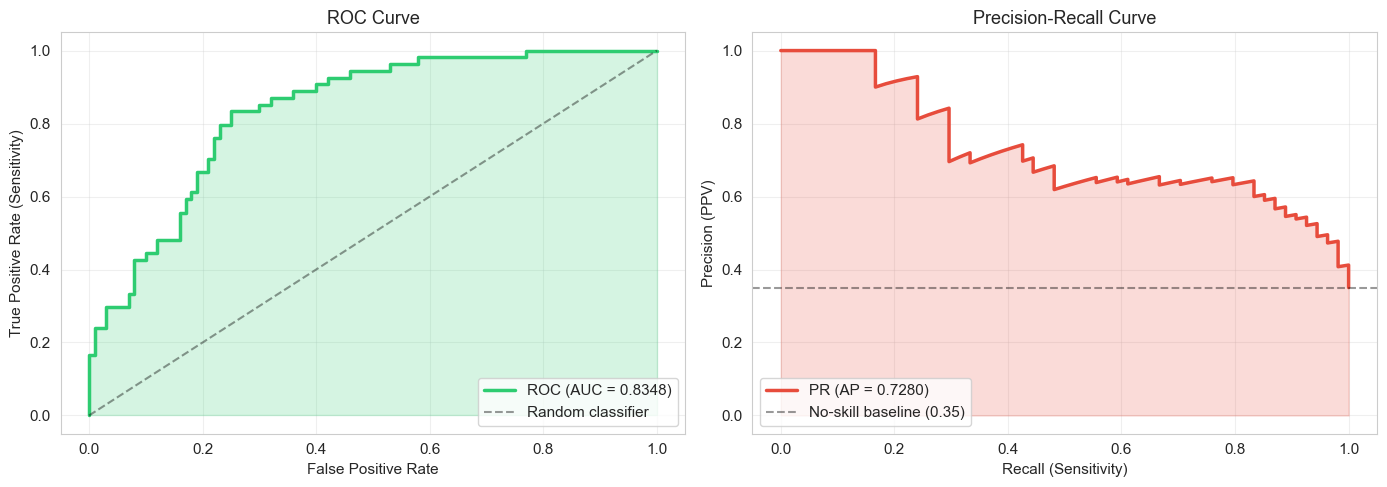

In [85]:
# ROC + PR Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'ROC (AUC = {metrics["ROC-AUC"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve', fontsize=13)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
baseline_pr = y_test.sum() / len(y_test)
axes[1].plot(recall_curve, precision_curve, color='#e74c3c', lw=2.5,
             label=f'PR (AP = {metrics["Average Precision"]:.4f})')
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.4,
                label=f'No-skill baseline ({baseline_pr:.2f})')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.2, color='#e74c3c')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

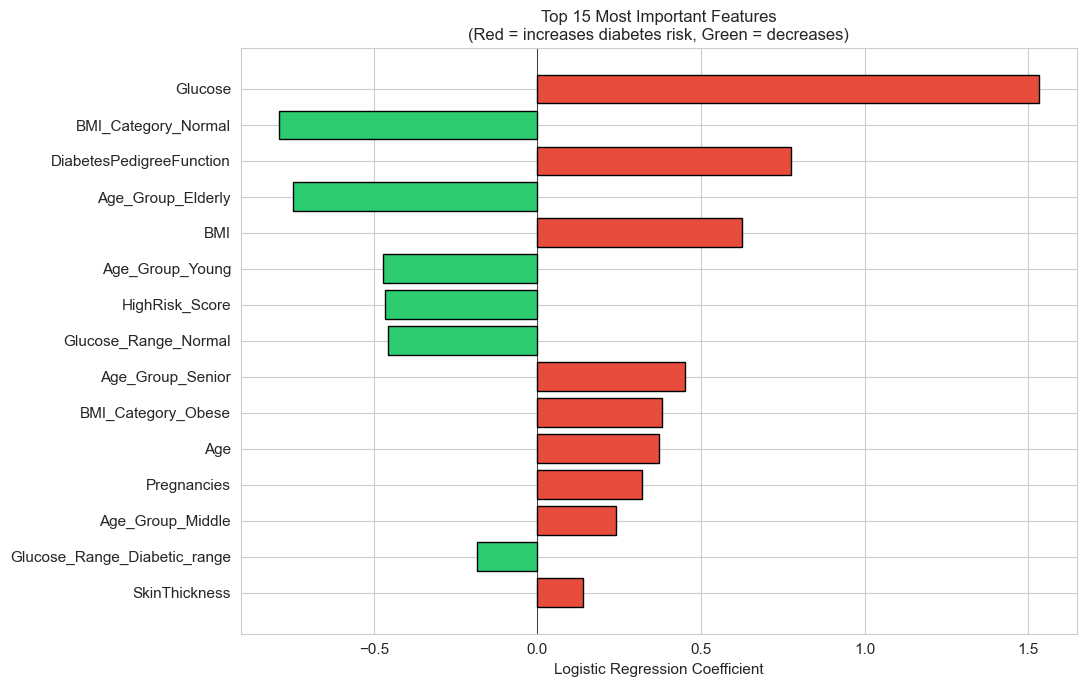


Clinical insight: Glucose_Range_Diabetic_range, BMI, Age and DiabetesPedigreeFunction
are the top risk factors, which lines up with established medical knowledge.


In [86]:
classifier = best_model.named_steps['classifier']
preproc = best_model.named_steps['preprocessor']

num_features = preproc.transformers_[0][2]
cat_features = preproc.transformers_[1][1].named_steps['encoder'].get_feature_names_out(
    preproc.transformers_[1][2])
all_feature_names = list(num_features) + list(cat_features)

coefs = classifier.coef_[0]
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefs,
    'abs_importance': np.abs(coefs)
}).sort_values('abs_importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in importance_df['coefficient'].values[::-1]]
ax.barh(range(len(importance_df)), importance_df['coefficient'].values[::-1], color=colors, edgecolor='black')
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df['feature'].values[::-1])
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Top 15 Most Important Features\n(Red = increases diabetes risk, Green = decreases)', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()
print("\nClinical insight: Glucose_Range_Diabetic_range, BMI, Age and DiabetesPedigreeFunction")
print("are the top risk factors, which lines up with established medical knowledge.")

---
## Save Model for Deployment

In [87]:
joblib.dump(best_model, 'diabetes_model.pkl')

metadata = {
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'all_features': list(X.columns),
    'medians': X[numerical_cols].median().to_dict(),
    'modes': {c: X[c].mode()[0] for c in categorical_cols},
    'unique_values': {c: sorted([str(v) for v in X[c].unique().tolist()]) for c in categorical_cols},
    'best_params': grid_search.best_params_,
    'final_metrics': {k: float(v) for k, v in metrics.items()}
}
joblib.dump(metadata, 'metadata.pkl')

print("Saved:")
print("  diabetes_model.pkl  (trained pipeline)")
print("  metadata.pkl        (UI defaults and metric values)")

Saved:
  diabetes_model.pkl  (trained pipeline)
  metadata.pkl        (UI defaults and metric values)


---
## Tasks 10 and 11 — Gradio Interface and Hugging Face Deployment

The Gradio app is designed to be usable by community health workers in resource-limited settings:
- Only 7 input fields, the measurements that any clinic can collect
- Risk tier output (Low / Moderate / High) instead of just a probability, so it is actionable for non-experts
- A clinical recommendation suggesting what action to take
- The engineered features are computed automatically in the backend

The full Gradio app is in `app.py` (separate file).

In [88]:
import joblib

loaded_model = joblib.load('diabetes_model.pkl')
loaded_meta = joblib.load('metadata.pkl')

sample = X_test.iloc[[0]]
pred = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]

print("Sample patient features:")
for col in ['Age', 'Glucose', 'BMI', 'BloodPressure', 'DiabetesPedigreeFunction']:
    print(f"  {col}: {sample[col].values[0]}")
print(f"\nPrediction: {'HIGH RISK - Diabetic' if pred == 1 else 'LOW RISK - Non-Diabetic'}")
print(f"Probability of diabetes: {proba[1]*100:.1f}%")

Sample patient features:
  Age: 40
  Glucose: 159.0
  BMI: 27.4
  BloodPressure: 64.0
  DiabetesPedigreeFunction: 0.294

Prediction: HIGH RISK - Diabetic
Probability of diabetes: 75.3%


### Deployment to Hugging Face Spaces

Follow the steps in `DEPLOYMENT_GUIDE.md` for full deployment instructions.

Quick summary:
1. Create a new Space on huggingface.co (SDK: Gradio)
2. Upload: `app.py`, `requirements.txt`, `diabetes_model.pkl`, `metadata.pkl`, `README.md`
3. Wait about 2 minutes for build
4. Test in an Incognito tab to verify public access

---

## Final Performance Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | 0.7662 |
| Test Precision | 0.6324 |
| Test Recall (Sensitivity) | 0.7963 |
| Test F1-Score | 0.7049 |
| Test ROC-AUC | 0.8348 |
| CV F1 (5-fold) | 0.6995 ± 0.046 |

## Real-World Context

With basic clinical measurements (Glucose, BMI, BP, Age, Pregnancies, Skin Thickness, Insulin, DiabetesPedigreeFunction), the model correctly identifies about 80% of diabetic patients in the test set. That sensitivity is high enough to make it useful as a community-level screening tool in resource-limited settings, where confirmatory lab tests are expensive but initial measurements are cheap.

For a country like Bangladesh with millions of undiagnosed diabetics, this kind of model could help community health workers triage patients for follow-up testing.